In [1]:
from google.colab import files

uploaded = files.upload()

Saving grocery_sales.csv to grocery_sales.csv


In [2]:
import pandas as pd

df = pd.read_csv("grocery_sales.csv")

df.head()

,customer_id,transaction_date,transaction_id,sales
0,58,2020-09-01,437091488759,29.93
1,80,2020-09-01,437092271839,11.50
2,41,2020-09-01,437093560410,101.56
3,25,2020-09-01,437096216909,83.01
4,2,2020-09-01,437096888457,NaN


In [3]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nSummary Statistics:")
display(df.describe(include="all"))

Shape: (281, 4)

Data Types:
customer_id           int64
transaction_date     object
transaction_id        int64
sales               float64
dtype: object

Missing Values:
customer_id         0
transaction_date    0
transaction_id      0
sales               4
dtype: int64

Duplicate Rows: 0

Summary Statistics:


,customer_id,transaction_date,transaction_id,sales
count,281.000000,281,2.810000e+02,277.000000
unique,NaN,30,NaN,NaN
top,NaN,2020-09-22,NaN,NaN
freq,NaN,15,NaN,NaN
mean,56.362989,NaN,4.372368e+11,56.127617
std,33.397229,NaN,1.067372e+08,52.427851
min,1.000000,NaN,4.361952e+11,2.380000
25%,23.000000,NaN,4.371646e+11,15.210000
50%,58.000000,NaN,4.372395e+11,36.280000
75%,89.000000,NaN,4.373118e+11,83.270000


Data Cleaning

In [4]:
# Convert transaction_date to datetime
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# Check the result
print(df.dtypes)

customer_id                  int64
transaction_date    datetime64[ns]
transaction_id               int64
sales                      float64
dtype: object


In [5]:
# Check missing sales records
df[df["sales"].isnull()]

,customer_id,transaction_date,transaction_id,sales
4,2,2020-09-01,437096888457,NaN
34,2,2020-09-04,437125584746,NaN
148,67,2020-09-17,437252078707,NaN
219,106,2020-09-24,437322710488,NaN


In [6]:
#Handle missing values
df[df["transaction_date"].isin(
    df.loc[df["sales"].isna(), "transaction_date"]
)].sort_values("transaction_date")

,customer_id,transaction_date,transaction_id,sales
0,58,2020-09-01,437091488759,29.93
1,80,2020-09-01,437092271839,11.50
2,41,2020-09-01,437093560410,101.56
3,25,2020-09-01,437096216909,83.01
4,2,2020-09-01,437096888457,NaN
5,93,2020-09-01,437097325535,5.59
6,31,2020-09-01,437097347269,12.98
7,4,2020-09-01,437098791146,78.79
36,1,2020-09-04,437127360389,158.38
35,67,2020-09-04,437127049139,3.18


In [7]:
# Keep the original dataset intact
df_clean = df.dropna(subset=["sales"]).copy()

print("Original records:", len(df))
print("Records used for sales analysis:", len(df_clean))
print("Missing sales removed:", df_clean["sales"].isna().sum())

Original records: 281
Records used for sales analysis: 277
Missing sales removed: 0


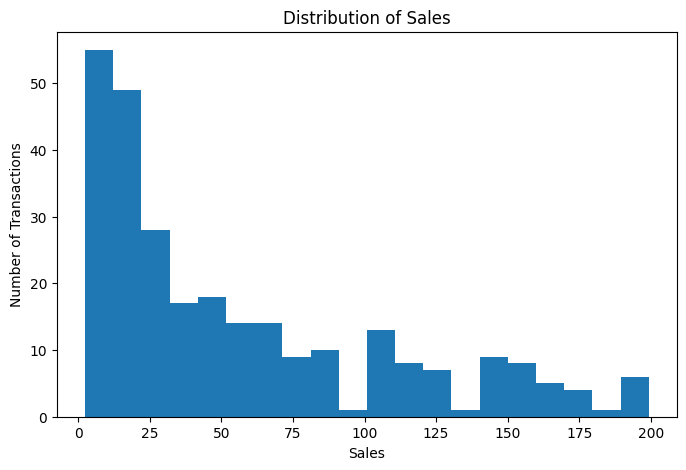

In [8]:
#Understand the sales distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df_clean["sales"], bins=20)
plt.xlabel("Sales")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Sales")
plt.show()

In [9]:
print("Mean:", df_clean["sales"].mean())
print("Median:", df_clean["sales"].median())
print("Standard Deviation:", df_clean["sales"].std())
print("Minimum:", df_clean["sales"].min())
print("Maximum:", df_clean["sales"].max())

Mean: 56.127617328519854
Median: 36.28
Standard Deviation: 52.427851004680484
Minimum: 2.38
Maximum: 199.27


In [10]:
#Check outliers
Q1 = df_clean["sales"].quantile(0.25)
Q3 = df_clean["sales"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[
    (df_clean["sales"] < lower_bound) |
    (df_clean["sales"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))

display(outliers)

Q1: 15.21
Q3: 83.27
IQR: 68.06
Lower Bound: -86.88
Upper Bound: 185.36
Number of Outliers: 6


,customer_id,transaction_date,transaction_id,sales
46,95,2020-09-06,437141489594,198.55
58,5,2020-09-07,437154332962,190.60
82,81,2020-09-10,437183040105,196.55
187,66,2020-09-21,437295776576,199.27
214,37,2020-09-23,437314230345,198.93
239,102,2020-09-27,437353354890,197.62


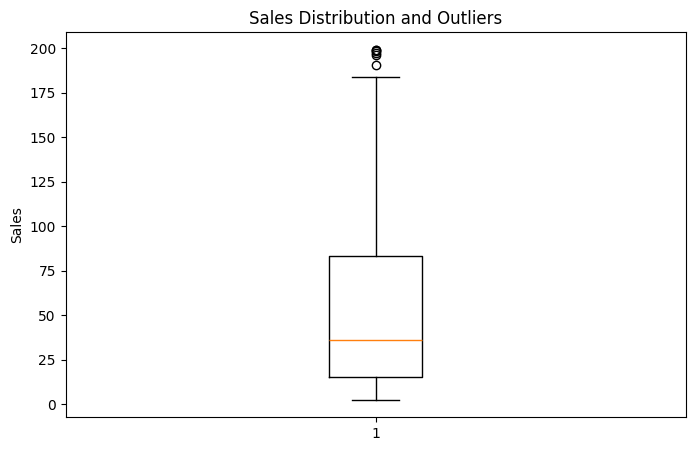

In [11]:
#Visualize the distribution properly
plt.figure(figsize=(8, 5))
plt.boxplot(df_clean["sales"])
plt.ylabel("Sales")
plt.title("Sales Distribution and Outliers")
plt.show()

In [12]:
#Then create a time-based view:
daily_sales = (
    df_clean.groupby("transaction_date")["sales"]
    .agg(["sum", "mean", "count"])
    .reset_index()
)

daily_sales.head()

,transaction_date,sum,mean,count
0,2020-09-01,323.36,46.194286,7
1,2020-09-02,656.37,59.670000,11
2,2020-09-03,465.05,42.277273,11
3,2020-09-04,433.90,72.316667,6
4,2020-09-05,222.98,27.872500,8


Daily Sales Trend

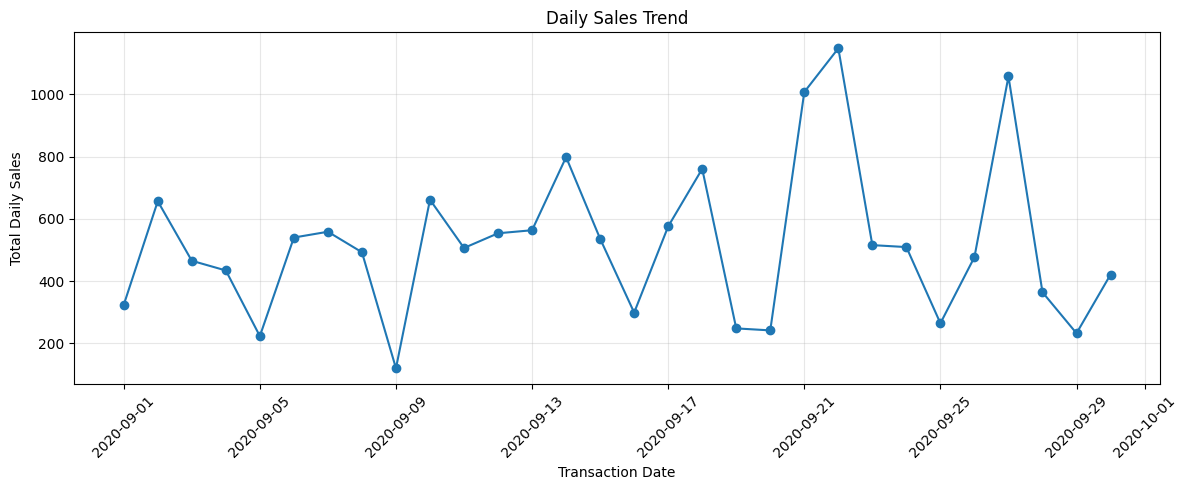

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales["transaction_date"],
    daily_sales["sum"],
    marker="o"
)

plt.xlabel("Transaction Date")
plt.ylabel("Total Daily Sales")
plt.title("Daily Sales Trend")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
highest_sales_day = daily_sales.loc[daily_sales["sum"].idxmax()]
lowest_sales_day = daily_sales.loc[daily_sales["sum"].idxmin()]

print("Highest sales day:")
display(highest_sales_day.to_frame().T)

print("\nLowest sales day:")
display(lowest_sales_day.to_frame().T)

Highest sales day:


,transaction_date,sum,mean,count
21,2020-09-22 00:00:00,1147.62,76.508,15



Lowest sales day:


,transaction_date,sum,mean,count
8,2020-09-09 00:00:00,119.7,23.94,5


Customer-level analysis

Now let's identify your highest-value customers.

In [15]:
customer_sales = (
    df_clean.groupby("customer_id")["sales"]
    .agg(["sum", "mean", "count"])
    .sort_values("sum", ascending=False)
    .reset_index()
)

customer_sales.head(10)

,customer_id,sum,mean,count
0,48,524.41,131.102500,4
1,37,444.92,88.984000,5
2,94,422.53,52.816250,8
3,102,422.14,84.428000,5
4,78,398.57,79.714000,5
5,41,395.84,79.168000,5
6,71,383.66,127.886667,3
7,18,372.13,124.043333,3
8,47,363.79,121.263333,3
9,106,360.02,72.004000,5


In [16]:
top_customer = customer_sales.iloc[0]

print("Top customer:")
print("Customer ID:", int(top_customer["customer_id"]))
print("Total Sales:", round(top_customer["sum"], 2))
print("Average Transaction:", round(top_customer["mean"], 2))
print("Number of Transactions:", int(top_customer["count"]))

Top customer:
Customer ID: 48
Total Sales: 524.41
Average Transaction: 131.1
Number of Transactions: 4


Top 10 Customers Visualization

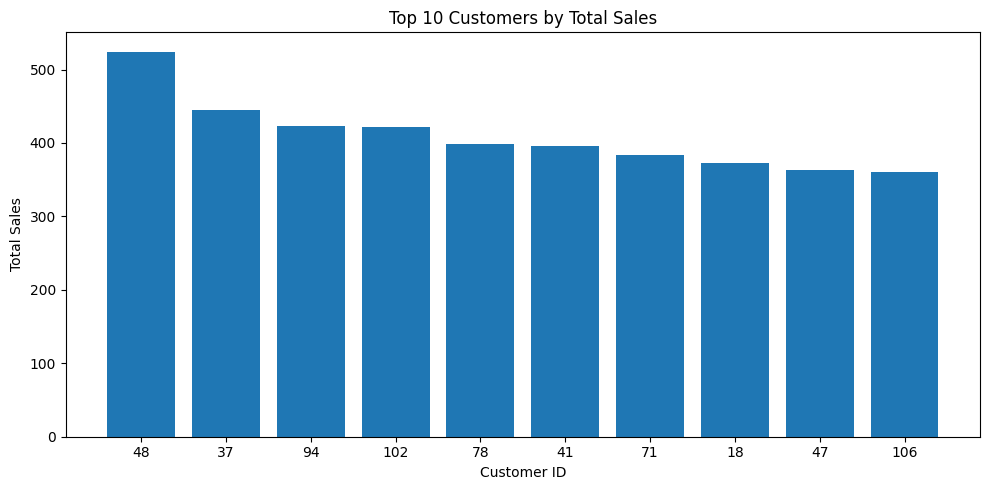

In [17]:
top_10_customers = customer_sales.head(10)

plt.figure(figsize=(10, 5))
plt.bar(
    top_10_customers["customer_id"].astype(str),
    top_10_customers["sum"]
)

plt.xlabel("Customer ID")
plt.ylabel("Total Sales")
plt.title("Top 10 Customers by Total Sales")
plt.tight_layout()
plt.show()

In [18]:
display(top_10_customers)

,customer_id,sum,mean,count
0,48,524.41,131.102500,4
1,37,444.92,88.984000,5
2,94,422.53,52.816250,8
3,102,422.14,84.428000,5
4,78,398.57,79.714000,5
5,41,395.84,79.168000,5
6,71,383.66,127.886667,3
7,18,372.13,124.043333,3
8,47,363.79,121.263333,3
9,106,360.02,72.004000,5


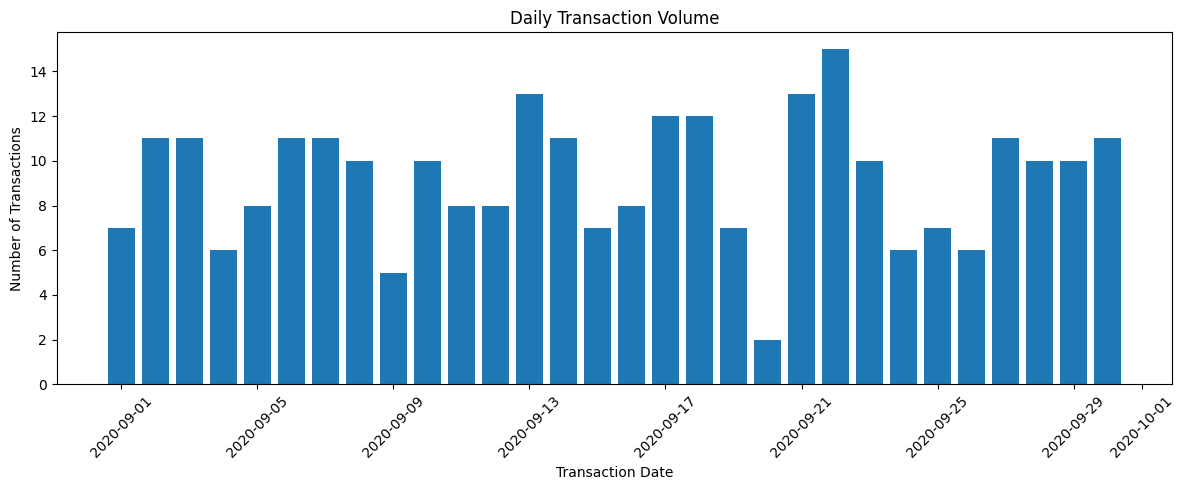

In [19]:
#Analyze transaction volume.
transaction_volume = (
    df_clean.groupby("transaction_date")
    .size()
    .reset_index(name="transactions")
)

plt.figure(figsize=(12, 5))
plt.bar(
    transaction_volume["transaction_date"],
    transaction_volume["transactions"]
)

plt.xlabel("Transaction Date")
plt.ylabel("Number of Transactions")
plt.title("Daily Transaction Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
print("Average daily transactions:", round(transaction_volume["transactions"].mean(), 2))
print("Maximum daily transactions:", transaction_volume["transactions"].max())
print("Minimum daily transactions:", transaction_volume["transactions"].min())

Average daily transactions: 9.23
Maximum daily transactions: 15
Minimum daily transactions: 2


In [21]:
#Measure the relationship between sales and transaction volume.
correlation = daily_sales["sum"].corr(daily_sales["count"])

print("Correlation between daily sales and transaction volume:",
      round(correlation, 3))

Correlation between daily sales and transaction volume: 0.694


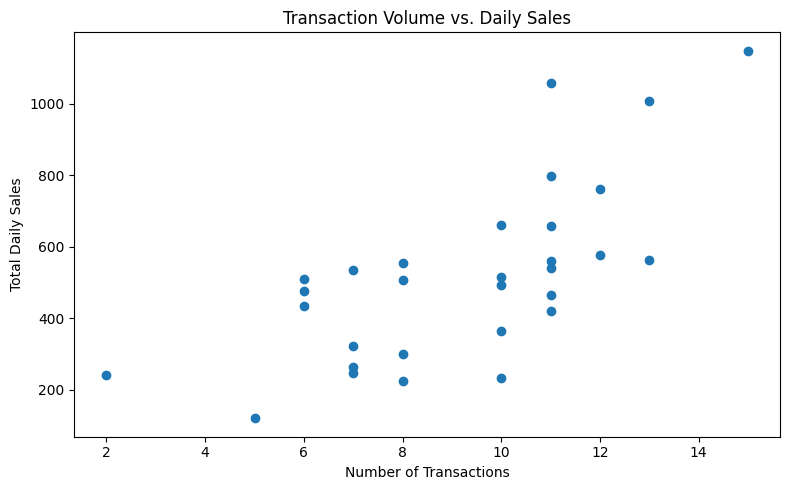

In [22]:
plt.figure(figsize=(8, 5))

plt.scatter(
    daily_sales["count"],
    daily_sales["sum"]
)

plt.xlabel("Number of Transactions")
plt.ylabel("Total Daily Sales")
plt.title("Transaction Volume vs. Daily Sales")
plt.tight_layout()
plt.show()

In [23]:
#Final analysis
#Now let's calculate the overall project KPIs.

total_sales = df_clean["sales"].sum()
total_transactions = len(df_clean)
unique_customers = df_clean["customer_id"].nunique()
average_transaction = df_clean["sales"].mean()


print("Total Sales:", round(total_sales, 2))
print("Total Transactions:", total_transactions)
print("Unique Customers:", unique_customers)
print("Average Transaction Value:", round(average_transaction, 2))

Total Sales: 15547.35
Total Transactions: 277
Unique Customers: 86
Average Transaction Value: 56.13


## Key Insights

1. The dataset contains 281 transactions across 30 days. After excluding four transactions with missing sales values, 277 transactions were analyzed.

2. Total recorded sales amounted to 15,547.35, with an average transaction value of 56.13.

3. The mean sales value (56.13) is higher than the median (36.28), indicating a right-skewed sales distribution.

4. Six high-value transactions were identified as statistical outliers. These were retained because they appear to represent genuine high-value purchases rather than data errors.

5. September 22 recorded the highest daily sales at 1,147.62, while September 9 recorded the lowest at 119.70.

6. Customer 48 generated the highest total sales at 524.41 across four transactions.

7. Daily transaction volume and total daily sales showed a correlation of 0.694, indicating a moderately strong positive relationship. However, correlation does not imply causation.

## Conclusion

The analysis demonstrates how exploratory data analysis can transform raw transactional data into meaningful business insights using Python. The project covers data cleaning, descriptive statistics, visualization, outlier analysis, customer analysis, time-based analysis, and correlation analysis.